**Disciplina**: Data Project: Discovery & Preparation

**Docente**: Roberto Santos

# PROJETO SIVIG-GILQ
## Sistema Inteligente de Vigilância Epidemiológica com Data Mining

 Grupo GILQ

**Discentes**:
- GABRIEL LIRA DE JESUS
- IGOR SANTIAGO MACEDO
- LUCIMARA DE ASSIS LEONCIO
- QUEZIA OLIVEIRA SILVA


## **INTRODUÇÃO**

A vigilância epidemiológica depende da identificação precoce de casos suspeitos, especialmente em doenças de notificação compulsória. Em serviços de urgência, pronto atendimentos, triagem em unidades de saúde, sinais vitais e queixas principais são registrados rotineiramente, porém nem sempre são transformados em alertas estruturados para apoio à decisão.

O projeto SIVIG-GILQ propõe o uso de Data Mining e Machine Learning para apoiar a triagem clínica e a vigilância epidemiológica, identificando padrões compatíveis com suspeita de dengue, leptospirose e meningite.

## 2. **PROBLEMA DE NEGÓCIO**

Sintomas inespecíficos podem representar um caso simples ou
início de um agravo e/ou de interesse epidemiológico.

Como a triagem não possui um mecanismo padronizado e automatizado para
identificar, em tempo real, casos suspeitos epidemiológicos, dependendo
exclusivamente da avaliação clínica manual, podendo gerar atraso na
identificação de casos suspeitos, demora na notificação, risco de subnotificação,
agravando a propagação da doença.

## 3. **OBJETIVO**

Desenvolver um modelo de Data Mining capaz de identificar casos suspeitos de dengue, leptospirose e meningite a partir de dados de triagem, sinais vitais e queixa principal.

Como produto final, o projeto propõe um alerta integrado para apoio à vigilância epidemiológica, com sugestão de espelhamento da ficha de investigação epidemiológica - FIE-SINAN e encaminhamento para avaliação da equipe responsável.

## 4. **METODOLOGIA CRISP-DM**

O projeto foi estruturado com base na metodologia CRISP-DM, contemplando as seguintes etapas:

1. Entendimento do problema: identificação da necessidade de apoio à vigilância epidemiológica.

2. Entendimento dos dados: análise das bases de triagem e atendimento.

3. Preparação dos dados: limpeza, padronização e tratamento de ruídos semânticos.

4. Modelagem: construção de modelos preditivos para dengue, leptospirose e meningite.

5. Avaliação: análise de desempenho por matriz de confusão, precision, recall e F1-score.

6. Implantação conceitual: geração de alerta integrado e proposta de espelhamento da ficha de investigação epidemiológica - FIE-SINAN.

## 5. **ENTENDIMENTO DOS DADOS**

Bases de Dados Utilizada

https://physionet.org/

https://physionet.org/content/mimic-iv-ed/2.2/

wget -r -N -c -np --user luci --ask-password https://physionet.org/files/mimic-iv-ed/2.2/

- MIMIC-IV-ED (PhysioNet):
  - triage.csv  
  - edstays.csv  

---
Observação Ética

Todos os dados utilizados são anonimizados e seguem as diretrizes internacionais de ética em pesquisa, incluindo conformidade com HIPAA e uso autorizado via PhysioNet.

---


Importamos as bibliotecas que serão utilizadas para leitura, manipulação e análise das bases de dados.

In [ ]:
import pandas as pd
import numpy as np
import re
import gc
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc


Carregamos as bases selecionadas do MIMIC-IV-ED para o ambiente de análise.
As tabelas escolhidas foram:

triage.csv: informações iniciais da triagem
edstays.csv: informações da permanência no pronto atendimento

In [ ]:
triage = pd.read_csv('triage.csv', engine='python', on_bad_lines='skip')
edstays = pd.read_csv('edstays.csv', engine='python', on_bad_lines='skip')

Visualizamos as primeiras linhas de cada tabela para compreender a estrutura dos dados, identificar colunas e verificar o conteúdo inicial.

In [ ]:
triage.head()
edstays.head()

,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,2180-05-06 23:30:00,F,WHITE,AMBULANCE,ADMITTED
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,2180-06-26 21:31:00,F,WHITE,AMBULANCE,ADMITTED
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,2180-08-06 01:44:00,F,WHITE,AMBULANCE,ADMITTED
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,2180-07-23 05:54:00,F,WHITE,AMBULANCE,HOME
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,2180-07-23 14:00:00,F,WHITE,AMBULANCE,ADMITTED


 Listamos os nomes das colunas de cada base para entender quais variáveis estão disponíveis e quais poderão ser utilizadas nas próximas etapas.

In [ ]:
print("Colunas da base triage:")
print(triage.columns)

print("\nColunas da base edstays:")
print(edstays.columns)

Colunas da base triage:
Index(['subject_id', 'stay_id', 'temperature', 'heartrate', 'resprate',
       'o2sat', 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint'],
      dtype='object')

Colunas da base edstays:
Index(['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'gender',
       'race', 'arrival_transport', 'disposition'],
      dtype='object')


Analisamos a quantidade de linhas e colunas de cada tabela.
Essa etapa é importante para entender o volume de dados e a dimensão de cada base.

In [ ]:
print("Triage:", triage.shape)
print("EdStays:", edstays.shape)

Triage: (425087, 11)
EdStays: (425087, 9)


 As bases do MIMIC-IV-ED são exportadas para o formato Excel com o objetivo de facilitar a inspeção visual e a compreensão inicial das tabelas.



In [ ]:
with pd.ExcelWriter('mimic_exploracao.xlsx') as writer:
    triage.to_excel(writer, sheet_name='triage', index=False)
    edstays.to_excel(writer, sheet_name='edstays', index=False)


As tabelas do MIMIC-IV-ED são integradas em uma única base analítica.

O objetivo é consolidar, em um único registro por atendimento, todas as informações relevantes para modelagem, incluindo dados de triagem, sinais vitais e diagnóstico.

Essa estrutura é necessária para aplicação de técnicas de machine learning.

In [ ]:
def adicionar_prefixo(df, prefixo, chaves=['subject_id', 'stay_id']):
    novas_colunas = {
        col: f'{prefixo}_{col}' for col in df.columns if col not in chaves
    }
    return df.rename(columns=novas_colunas)

triage_p = adicionar_prefixo(triage, 'triage')
edstays_p = adicionar_prefixo(edstays, 'edstays')

tabela = triage_p.merge(
    edstays_p,
    on=['subject_id', 'stay_id'],
    how='left'
)

print("Dimensão da tabela:", tabela.shape)
display(tabela.head())

Dimensão da tabela: (425087, 18)


,subject_id,stay_id,triage_temperature,triage_heartrate,triage_resprate,triage_o2sat,triage_sbp,triage_dbp,triage_pain,triage_acuity,triage_chiefcomplaint,edstays_hadm_id,edstays_intime,edstays_outtime,edstays_gender,edstays_race,edstays_arrival_transport,edstays_disposition
0,10000032,32952584,97.8,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension,29079034.0,2180-07-22 16:24:00,2180-07-23 05:54:00,F,WHITE,AMBULANCE,HOME
1,10000032,33258284,98.4,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention",22595853.0,2180-05-06 19:17:00,2180-05-06 23:30:00,F,WHITE,AMBULANCE,ADMITTED
2,10000032,35968195,99.4,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain",25742920.0,2180-08-05 20:58:00,2180-08-06 01:44:00,F,WHITE,AMBULANCE,ADMITTED
3,10000032,38112554,98.9,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention,22841357.0,2180-06-26 15:54:00,2180-06-26 21:31:00,F,WHITE,AMBULANCE,ADMITTED
4,10000032,39399961,98.7,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC",29079034.0,2180-07-23 05:54:00,2180-07-23 14:00:00,F,WHITE,AMBULANCE,ADMITTED


## 6. **PREPARAÇÃO E TRATAMENTO DE DADOS**

Nesta etapa foram realizadas a limpeza e padronização das variáveis clínicas. A queixa principal foi tratada para remoção de ruídos semânticos e normalização de termos leigos.

Exemplos de tratamento:

- remoção de termos sem valor clínico;
- padronização de expressões clínicas;
- conversão de sinais e sintomas em variáveis binárias;
- criação de variáveis derivadas a partir dos sinais vitais.

Esse processo permitiu transformar texto clínico livre em variáveis estruturadas para modelagem.

In [ ]:
# Converter temperatura de Fahrenheit para Celsius
tabela['temperatura'] = ((tabela['triage_temperature'] - 32) * 5/9).round(1)

# Renomear variáveis principais
tabela.rename(columns={
    'triage_temperature': 'temperatura_f',
    'triage_heartrate': 'fc',
    'triage_resprate': 'fr',
    'triage_o2sat': 'saturacao',
    'triage_sbp': 'pa_sistolica',
    'triage_dbp': 'pa_diastolica',
    'triage_pain': 'dor',
    'triage_chiefcomplaint': 'queixa_principal'
}, inplace=True)

# Padronizar texto da queixa principal
tabela['queixa_principal'] = tabela['queixa_principal'].fillna('').astype(str)
tabela['queixa_principal'] = tabela['queixa_principal'].str.lower().str.strip()

# Separar sintomas descritos na queixa principal
tabela['sintomas_lista'] = tabela['queixa_principal'].str.split(',')
tabela['sintomas_lista'] = tabela['sintomas_lista'].apply(
    lambda x: [i.strip() for i in x if i.strip() != '']
)

sintomas_expandido = tabela['sintomas_lista'].apply(pd.Series)
sintomas_expandido.columns = [f'sintoma_{i+1}' for i in sintomas_expandido.columns]

tabela = pd.concat([tabela, sintomas_expandido], axis=1)

display(tabela[['queixa_principal'] + [c for c in tabela.columns if c.startswith('sintoma_')][:6]].head())


,queixa_principal,sintoma_1,sintoma_2,sintoma_3,sintoma_4,sintoma_5,sintoma_6
0,hypotension,hypotension,NaN,NaN,NaN,NaN,NaN
1,"abd pain, abdominal distention",abd pain,abdominal distention,NaN,NaN,NaN,NaN
2,"n/v/d, abd pain",n/v/d,abd pain,NaN,NaN,NaN,NaN
3,abdominal distention,abdominal distention,NaN,NaN,NaN,NaN,NaN
4,"abdominal distention, abd pain, lethagic",abdominal distention,abd pain,lethagic,NaN,NaN,NaN


In [ ]:
colunas_base = [
    'subject_id',
    'stay_id',
    'edstays_gender',
    'edstays_race',
    'edstays_intime',
    'edstays_arrival_transport',
    'temperatura',
    'fc',
    'fr',
    'saturacao',
    'pa_sistolica',
    'pa_diastolica',
    'dor',
    'queixa_principal',
    'edstays_outtime',
    'edstays_disposition'
]

colunas_sintomas = [col for col in tabela.columns if col.startswith('sintoma_')][:6]

tabela_final = tabela[
    [col for col in colunas_base if col in tabela.columns] + colunas_sintomas
].copy()

print("Tabela final:", tabela_final.shape)
display(tabela_final.head())


Tabela final: (425087, 22)


,subject_id,stay_id,edstays_gender,edstays_race,edstays_intime,edstays_arrival_transport,temperatura,fc,fr,saturacao,...,dor,queixa_principal,edstays_outtime,edstays_disposition,sintoma_1,sintoma_2,sintoma_3,sintoma_4,sintoma_5,sintoma_6
0,10000032,32952584,F,WHITE,2180-07-22 16:24:00,AMBULANCE,36.6,87.0,14.0,97.0,...,7,hypotension,2180-07-23 05:54:00,HOME,hypotension,NaN,NaN,NaN,NaN,NaN
1,10000032,33258284,F,WHITE,2180-05-06 19:17:00,AMBULANCE,36.9,70.0,16.0,97.0,...,0,"abd pain, abdominal distention",2180-05-06 23:30:00,ADMITTED,abd pain,abdominal distention,NaN,NaN,NaN,NaN
2,10000032,35968195,F,WHITE,2180-08-05 20:58:00,AMBULANCE,37.4,105.0,18.0,96.0,...,10,"n/v/d, abd pain",2180-08-06 01:44:00,ADMITTED,n/v/d,abd pain,NaN,NaN,NaN,NaN
3,10000032,38112554,F,WHITE,2180-06-26 15:54:00,AMBULANCE,37.2,88.0,18.0,97.0,...,10,abdominal distention,2180-06-26 21:31:00,ADMITTED,abdominal distention,NaN,NaN,NaN,NaN,NaN
4,10000032,39399961,F,WHITE,2180-07-23 05:54:00,AMBULANCE,37.1,77.0,16.0,98.0,...,13,"abdominal distention, abd pain, lethagic",2180-07-23 14:00:00,ADMITTED,abdominal distention,abd pain,lethagic,NaN,NaN,NaN


## 7. **ENGENHARIA DAS VARIAVEIS**

In [ ]:
if 'edstays_intime' in tabela_final.columns:
    tabela_final['edstays_intime'] = pd.to_datetime(tabela_final['edstays_intime'], errors='coerce')
    tabela_final['ano'] = tabela_final['edstays_intime'].dt.year
    tabela_final['mes'] = tabela_final['edstays_intime'].dt.month
    tabela_final['hora'] = tabela_final['edstays_intime'].dt.hour

display(tabela_final[['edstays_intime', 'ano', 'mes', 'hora']].head())


,edstays_intime,ano,mes,hora
0,2180-07-22 16:24:00,2180,7,16
1,2180-05-06 19:17:00,2180,5,19
2,2180-08-05 20:58:00,2180,8,20
3,2180-06-26 15:54:00,2180,6,15
4,2180-07-23 05:54:00,2180,7,5


In [ ]:
# Temperatura
tabela_final['temperatura'] = pd.to_numeric(tabela_final['temperatura'], errors='coerce')
tabela_final['febre'] = tabela_final['temperatura'].apply(lambda x: 1 if pd.notna(x) and x >= 38 else 0)

def classificar_febre(x):
    if pd.isna(x):
        return 0
    if x >= 39:
        return 2
    if x >= 38:
        return 1
    return 0

tabela_final['febre_classificada'] = tabela_final['temperatura'].apply(classificar_febre)

# Frequência cardíaca
tabela_final['fc'] = pd.to_numeric(tabela_final['fc'], errors='coerce')
tabela_final['taquicardia'] = tabela_final['fc'].apply(lambda x: 1 if pd.notna(x) and x > 100 else 0)

def classificar_fc(x):
    if pd.isna(x):
        return 0
    if x > 120:
        return 2
    if x > 100:
        return 1
    return 0

tabela_final['fc_classificada'] = tabela_final['fc'].apply(classificar_fc)

# Frequência respiratória
tabela_final['fr'] = pd.to_numeric(tabela_final['fr'], errors='coerce')
tabela_final['taquipneia'] = tabela_final['fr'].apply(lambda x: 1 if pd.notna(x) and x > 20 else 0)

def classificar_fr(x):
    if pd.isna(x):
        return 0
    if x > 30:
        return 2
    if x > 20:
        return 1
    return 0

tabela_final['fr_classificada'] = tabela_final['fr'].apply(classificar_fr)

# Saturação
tabela_final['saturacao'] = pd.to_numeric(tabela_final['saturacao'], errors='coerce')
tabela_final['hipoxemia'] = tabela_final['saturacao'].apply(lambda x: 1 if pd.notna(x) and x < 95 else 0)

def classificar_saturacao(x):
    if pd.isna(x):
        return 0
    if x < 90:
        return 2
    if x < 95:
        return 1
    return 0

tabela_final['saturacao_classificada'] = tabela_final['saturacao'].apply(classificar_saturacao)

# Pressão arterial sistólica
tabela_final['pa_sistolica'] = pd.to_numeric(tabela_final['pa_sistolica'], errors='coerce')
tabela_final['hipotensao'] = tabela_final['pa_sistolica'].apply(lambda x: 1 if pd.notna(x) and x < 90 else 0)
tabela_final['hipertensao'] = tabela_final['pa_sistolica'].apply(lambda x: 1 if pd.notna(x) and x >= 140 else 0)

def classificar_pa_sistolica(x):
    if pd.isna(x):
        return 0
    if x < 90:
        return 1
    if x >= 180:
        return 3
    if x >= 140:
        return 2
    return 0

tabela_final['pa_sistolica_classificada'] = tabela_final['pa_sistolica'].apply(classificar_pa_sistolica)

# Pressão arterial diastólica
tabela_final['pa_diastolica'] = pd.to_numeric(tabela_final['pa_diastolica'], errors='coerce')
tabela_final['hipertensao_diastolica'] = tabela_final['pa_diastolica'].apply(
    lambda x: 1 if pd.notna(x) and x >= 90 else 0
)

# Dor
tabela_final['dor'] = pd.to_numeric(tabela_final['dor'], errors='coerce').fillna(0)

def classificar_dor(x):
    if pd.isna(x):
        return 0
    if x >= 7:
        return 3
    if x >= 4:
        return 2
    if x > 0:
        return 1
    return 0

tabela_final['dor_escala'] = tabela_final['dor'].apply(classificar_dor)
tabela_final['dor_relevante'] = tabela_final['dor'].apply(lambda x: 1 if pd.notna(x) and x >= 4 else 0)

display(tabela_final[[
    'temperatura', 'febre', 'febre_classificada',
    'fc', 'taquicardia', 'fr', 'taquipneia',
    'saturacao', 'hipoxemia',
    'pa_sistolica', 'hipotensao',
    'dor', 'dor_relevante'
]].head())


,temperatura,febre,febre_classificada,fc,taquicardia,fr,taquipneia,saturacao,hipoxemia,pa_sistolica,hipotensao,dor,dor_relevante
0,36.6,0,0,87.0,0,14.0,0,97.0,0,71.0,1,7.0,1
1,36.9,0,0,70.0,0,16.0,0,97.0,0,106.0,0,0.0,0
2,37.4,0,0,105.0,1,18.0,0,96.0,0,106.0,0,10.0,1
3,37.2,0,0,88.0,0,18.0,0,97.0,0,116.0,0,10.0,1
4,37.1,0,0,77.0,0,16.0,0,98.0,0,96.0,0,13.0,1


In [ ]:
colunas_sintomas = [col for col in tabela_final.columns if col.startswith('sintoma_')]

def normalizar_texto(texto):
    if pd.isna(texto):
        return ''
    texto = str(texto).lower().strip()
    texto = texto.replace('"', '').replace("'", '')
    texto = re.sub(r'\s+', ' ', texto)
    return texto

ruidos_semanticos = [
    "broken heart",
    "telekinesis",
    "i was mad",
    "scared"
]

ruidos_semanticos = [normalizar_texto(x) for x in ruidos_semanticos]

for col in colunas_sintomas:
    tabela_final[col] = tabela_final[col].apply(normalizar_texto)
    tabela_final[col] = tabela_final[col].apply(
        lambda x: np.nan if x in ruidos_semanticos else x
    )

print("Ruídos semânticos removidos.")
display(tabela_final[colunas_sintomas].head())


Ruídos semânticos removidos.


,sintoma_1,sintoma_2,sintoma_3,sintoma_4,sintoma_5,sintoma_6
0,hypotension,,,,,
1,abd pain,abdominal distention,,,,
2,n/v/d,abd pain,,,,
3,abdominal distention,,,,,
4,abdominal distention,abd pain,lethagic,,,


In [ ]:
df_modelo = tabela_final.copy()

# Identificar colunas sintoma_1, sintoma_2, ...
colunas_sintomas_texto = [
    col for col in df_modelo.columns
    if col.startswith("sintoma_")
]

print("Colunas de sintomas encontradas:", colunas_sintomas_texto)

# ------------------------------------------------------------
# Função leve de limpeza de texto
# ------------------------------------------------------------

def limpar_texto(texto):
    if pd.isna(texto):
        return ""

    texto = str(texto).lower().strip()
    texto = re.sub(r"[^a-z0-9]+", "_", texto)
    texto = texto.strip("_")

    return texto


# ------------------------------------------------------------
# Mapa clínico padronizado
# ------------------------------------------------------------

mapa_sintomas = {
    "fever": ["febre"],
    "fevers": ["febre"],
    "headache": ["cefaleia"],

    "nausea": ["nausea"],
    "n_v": ["nausea", "vomito"],
    "n_v_d": ["nausea", "vomito", "diarreia"],
    "vomiting": ["vomito"],
    "vomit": ["vomito"],
    "diarrhea": ["diarreia"],

    "sob": ["dispneia"],
    "dyspnea": ["dispneia"],
    "shortness_of_breath": ["dispneia"],

    "chills": ["calafrios"],
    "weakness": ["fraqueza"],
    "malaise": ["mal_estar"],
    "feels_sick": ["mal_estar"],

    "heart_racing": ["taquicardia"],
    "tachycardia": ["taquicardia"],

    "seizure": ["convulsao"],
    "seizures": ["convulsao"],

    "pain": ["dor"],
    "body_aches": ["mialgia"],
    "myalgia": ["mialgia"],

    "abd_pain": ["dor_abdominal"],
    "abdominal_pain": ["dor_abdominal"],
    "abdominal_distention": ["distensao_abdominal"],

    "jaundice": ["ictericia"],
    "yellow": ["ictericia"]
}

# ------------------------------------------------------------
# Criar lista fixa de sintomas finais
# Isso evita criar centenas de colunas desnecessárias
# ------------------------------------------------------------

sintomas_finais = sorted(
    set(
        sintoma
        for lista in mapa_sintomas.values()
        for sintoma in lista
    )
)

print("Sintomas finais padronizados:")
print(sintomas_finais)

# ------------------------------------------------------------
# Inicializar colunas binárias com 0
# ------------------------------------------------------------

for sintoma in sintomas_finais:
    if sintoma not in df_modelo.columns:
        df_modelo[sintoma] = 0
    else:
        df_modelo[sintoma] = df_modelo[sintoma].fillna(0).astype(int)

# ------------------------------------------------------------
# Binarizar sintomas de forma otimizada
# ------------------------------------------------------------

for col in colunas_sintomas_texto:

    serie_limpa = df_modelo[col].apply(limpar_texto)

    for termo, sintomas_convertidos in mapa_sintomas.items():

        mascara = serie_limpa == termo

        if mascara.any():
            for sintoma in sintomas_convertidos:
                df_modelo.loc[mascara, sintoma] = 1

    del serie_limpa
    gc.collect()

# ------------------------------------------------------------
# Remover colunas textuais sintoma_1, sintoma_2...
# ------------------------------------------------------------

df_modelo = df_modelo.drop(columns=colunas_sintomas_texto, errors="ignore")

# ------------------------------------------------------------
# Resultado
# ------------------------------------------------------------

print("Sintomas binarizados com sucesso.")
print("Dimensão final:", df_modelo.shape)

display(df_modelo.head())


Colunas de sintomas encontradas: ['sintoma_1', 'sintoma_2', 'sintoma_3', 'sintoma_4', 'sintoma_5', 'sintoma_6']
Sintomas finais padronizados:
['calafrios', 'cefaleia', 'convulsao', 'diarreia', 'dispneia', 'distensao_abdominal', 'dor', 'dor_abdominal', 'febre', 'fraqueza', 'ictericia', 'mal_estar', 'mialgia', 'nausea', 'taquicardia', 'vomito']
Sintomas binarizados com sucesso.
Dimensão final: (425087, 46)


,subject_id,stay_id,edstays_gender,edstays_race,edstays_intime,edstays_arrival_transport,temperatura,fc,fr,saturacao,...,diarreia,dispneia,distensao_abdominal,dor_abdominal,fraqueza,ictericia,mal_estar,mialgia,nausea,vomito
0,10000032,32952584,F,WHITE,2180-07-22 16:24:00,AMBULANCE,36.6,87.0,14.0,97.0,...,0,0,0,0,0,0,0,0,0,0
1,10000032,33258284,F,WHITE,2180-05-06 19:17:00,AMBULANCE,36.9,70.0,16.0,97.0,...,0,0,1,1,0,0,0,0,0,0
2,10000032,35968195,F,WHITE,2180-08-05 20:58:00,AMBULANCE,37.4,105.0,18.0,96.0,...,1,0,0,1,0,0,0,0,1,1
3,10000032,38112554,F,WHITE,2180-06-26 15:54:00,AMBULANCE,37.2,88.0,18.0,97.0,...,0,0,1,0,0,0,0,0,0,0
4,10000032,39399961,F,WHITE,2180-07-23 05:54:00,AMBULANCE,37.1,77.0,16.0,98.0,...,0,0,1,1,0,0,0,0,0,0


In [ ]:
df_modelo['queixa_principal_limpa'] = (
    df_modelo['queixa_principal']
    .astype(str)
    .str.lower()
    .str.strip()
)

df_modelo['dor_abdominal'] = df_modelo['queixa_principal_limpa'].str.contains(
    r'abd pain|abdominal pain|lower abdominal pain',
    regex=True,
    na=False
).astype(int)

df_modelo['distensao_abdominal'] = df_modelo['queixa_principal_limpa'].str.contains(
    r'abdominal distention|abd distention|distention',
    regex=True,
    na=False
).astype(int)

df_modelo['ictericia'] = df_modelo['queixa_principal_limpa'].str.contains(
    r'jaundice|yellow|icteric',
    regex=True,
    na=False
).astype(int)

print("Dor abdominal:", df_modelo['dor_abdominal'].sum())
print("Distensão abdominal:", df_modelo['distensao_abdominal'].sum())
print("Icterícia:", df_modelo['ictericia'].sum())


Dor abdominal: 48199
Distensão abdominal: 1537
Icterícia: 938


In [ ]:
colunas_remover_baixa_relevancia = [
    'transfer',
    'r_numbness',
    'urinary_frequency',
    'difficulty_swallowing'
]

df_modelo = df_modelo.drop(
    columns=[col for col in colunas_remover_baixa_relevancia if col in df_modelo.columns]
)

print("Base após remoção:", df_modelo.shape)


Base após remoção: (425087, 47)


## 8. **DEFINIÇÃO DAS VRIÁVEIS ALVO**

As variáveis-alvo foram construídas a partir de critérios clínico-epidemiológicos, conforme definição de caso preconizado pelo ministério da saúde, simulando a identificação de casos suspeitos.

Foram criadas três variáveis binárias:

- suspeita_dengue
- suspeita_leptospirose
- suspeita_meningite

Cada variável assume valor 1 quando o paciente apresenta critérios compatíveis com suspeita clínica e 0 quando não apresenta.

In [ ]:
def tem_sintoma(row, sintoma):
    return row.get(sintoma, 0) == 1

# DENGUE
def classificar_dengue(row):
    sintomas = [
        tem_sintoma(row, 'cefaleia'),
        tem_sintoma(row, 'dor'),
        tem_sintoma(row, 'mialgia'),
        tem_sintoma(row, 'nausea'),
        tem_sintoma(row, 'vomito')
    ]

    if row.get('febre', 0) == 1 and sum(sintomas) >= 2:
        return 1
    return 0

# LEPTOSPIROSE
def classificar_leptospirose(row):
    criterio_1 = row.get('febre', 0) == 1

    criterio_2 = (
        row.get('mialgia', 0) == 1 or
        row.get('dor', 0) == 1 or
        row.get('dor_abdominal', 0) == 1
    )

    criterio_3 = (
        row.get('ictericia', 0) == 1 or
        row.get('vomito', 0) == 1 or
        row.get('nausea', 0) == 1 or
        row.get('distensao_abdominal', 0) == 1
    )

    if criterio_1 and criterio_2 and criterio_3:
        return 1
    return 0

# MENINGITE
def classificar_meningite(row):
    if (
        row.get('febre', 0) == 1 and
        tem_sintoma(row, 'cefaleia') and
        (
            tem_sintoma(row, 'vomito') or
            tem_sintoma(row, 'confusao') or
            tem_sintoma(row, 'rigidez_nuca') or
            tem_sintoma(row, 'convulsao')
        )
    ):
        return 1
    return 0

df_modelo['suspeita_dengue'] = df_modelo.apply(classificar_dengue, axis=1)
df_modelo['suspeita_leptospirose'] = df_modelo.apply(classificar_leptospirose, axis=1)
df_modelo['suspeita_meningite'] = df_modelo.apply(classificar_meningite, axis=1)

print("Dengue:", df_modelo['suspeita_dengue'].sum())
print("Leptospirose:", df_modelo['suspeita_leptospirose'].sum())
print("Meningite:", df_modelo['suspeita_meningite'].sum())


Dengue: 851
Leptospirose: 256
Meningite: 34


In [ ]:
df_modelo.to_csv("SIVIG_BASE_atualizada.csv", index=False)

print("Base salva como SIVIG_BASE_atualizada.csv")
print(df_modelo.shape)


Base salva como SIVIG_BASE_atualizada.csv
(425087, 50)


**MUDANÇA DE ESTRATÉGIA**

## Justificativa da Estratégia de Modelagem

Inicialmente, o SIVIG-GILQ foi pensado como um modelo de score clínico, no qual sinais e sintomas receberiam pesos para gerar uma pontuação de suspeita epidemiológica.

Durante a preparação dos dados, observou-se que a base estruturada permitia avançar para uma abordagem preditiva supervisionada. Assim, optou-se por treinar modelos de Machine Learning para dengue, leptospirose e meningite, utilizando as variáveis clínicas extraídas da triagem.

A abordagem preditiva permite avaliar o desempenho com métricas objetivas, como recall, precision, F1-score e matriz de confusão. Essa decisão é especialmente importante em vigilância epidemiológica, pois permite ajustar limiares para reduzir falsos negativos em doenças graves.

O score clínico permanece como uma possibilidade de camada interpretável do sistema, podendo ser usado futuramente para explicar ao profissional de saúde quais sinais contribuíram para o alerta gerado.

## 9. **MODELAGEM PREDITIVA**

* Modelo 1 - Dengue

* Modelo 2 - Leptospirose

* Modelo 3 - Meningite

Foram desenvolvidos três modelos independentes de classificação binária.

A escolha por modelos independentes permite que um mesmo paciente apresente mais de uma suspeita simultânea, refletindo a complexidade da triagem clínica real.

In [ ]:
def preparar_X_y(df, target):
    y = df[target]

    colunas_remover = [
        'suspeita_dengue',
        'suspeita_leptospirose',
        'suspeita_meningite',
        'subject_id',
        'stay_id',
        'queixa_principal',
        'queixa_principal_limpa'
    ]

    X = df.drop(columns=[col for col in colunas_remover if col in df.columns])

    colunas_data = X.select_dtypes(include=['datetime64[ns]', 'datetimetz']).columns
    X = X.drop(columns=colunas_data)

    colunas_categoricas_permitidas = [
        'edstays_gender',
        'edstays_arrival_transport'
    ]

    colunas_categoricas_existentes = [
        col for col in colunas_categoricas_permitidas
        if col in X.columns
    ]

    colunas_texto = X.select_dtypes(include=['object']).columns.tolist()
    colunas_texto_remover = [
        col for col in colunas_texto
        if col not in colunas_categoricas_existentes
    ]

    X = X.drop(columns=colunas_texto_remover)

    X = pd.get_dummies(
        X,
        columns=colunas_categoricas_existentes,
        drop_first=True
    )

    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

    return X, y


MODELO 1 - DENGUE

In [ ]:
X_dengue, y_dengue = preparar_X_y(df_modelo, 'suspeita_dengue')

X_train_dengue, X_test_dengue, y_train_dengue, y_test_dengue = train_test_split(
    X_dengue,
    y_dengue,
    test_size=0.3,
    random_state=42,
    stratify=y_dengue
)

modelo_dengue = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

modelo_dengue.fit(X_train_dengue, y_train_dengue)

y_pred_dengue = modelo_dengue.predict(X_test_dengue)
y_prob_dengue = modelo_dengue.predict_proba(X_test_dengue)[:, 1]

# Limiar ajustado para vigilância
y_pred_dengue_ajustado = (y_prob_dengue > 0.3).astype(int)

print("Treino:", X_train_dengue.shape)
print("Teste:", X_test_dengue.shape)
print(classification_report(y_test_dengue, y_pred_dengue_ajustado))
print(confusion_matrix(y_test_dengue, y_pred_dengue_ajustado))


Treino: (297560, 42)
Teste: (127527, 42)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    127272
           1       1.00      0.95      0.97       255

    accuracy                           1.00    127527
   macro avg       1.00      0.97      0.99    127527
weighted avg       1.00      1.00      1.00    127527

[[127272      0]
 [    13    242]]


MODELO 2 LEPTOSPIROSE

In [ ]:
X_lepto, y_lepto = preparar_X_y(df_modelo, 'suspeita_leptospirose')

X_train_lepto, X_test_lepto, y_train_lepto, y_test_lepto = train_test_split(
    X_lepto,
    y_lepto,
    test_size=0.3,
    random_state=42,
    stratify=y_lepto
)

modelo_lepto = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

modelo_lepto.fit(X_train_lepto, y_train_lepto)

y_pred_lepto = modelo_lepto.predict(X_test_lepto)
y_prob_lepto = modelo_lepto.predict_proba(X_test_lepto)[:, 1]

# Limiar ajustado para vigilância
y_pred_lepto_ajustado = (y_prob_lepto > 0.2).astype(int)

print("Treino:", X_train_lepto.shape)
print("Teste:", X_test_lepto.shape)
print(classification_report(y_test_lepto, y_pred_lepto_ajustado))
print(confusion_matrix(y_test_lepto, y_pred_lepto_ajustado))


Treino: (297560, 42)
Teste: (127527, 42)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    127450
           1       1.00      0.92      0.96        77

    accuracy                           1.00    127527
   macro avg       1.00      0.96      0.98    127527
weighted avg       1.00      1.00      1.00    127527

[[127450      0]
 [     6     71]]


MODELO 3 - MENINGITE

In [ ]:
X_meningite, y_meningite = preparar_X_y(df_modelo, 'suspeita_meningite')

X_train_men, X_test_men, y_train_men, y_test_men = train_test_split(
    X_meningite,
    y_meningite,
    test_size=0.3,
    random_state=42,
    stratify=y_meningite
)

modelo_meningite = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

modelo_meningite.fit(X_train_men, y_train_men)

y_pred_men = modelo_meningite.predict(X_test_men)
y_prob_men = modelo_meningite.predict_proba(X_test_men)[:, 1]

# Limiar ajustado para máxima sensibilidade
y_pred_men_ajustado = (y_prob_men > 0.1).astype(int)

print("Treino:", X_train_men.shape)
print("Teste:", X_test_men.shape)
print(classification_report(y_test_men, y_pred_men_ajustado))
print(confusion_matrix(y_test_men, y_pred_men_ajustado))


Treino: (297560, 42)
Teste: (127527, 42)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    127517
           1       0.90      0.90      0.90        10

    accuracy                           1.00    127527
   macro avg       0.95      0.95      0.95    127527
weighted avg       1.00      1.00      1.00    127527

[[127516      1]
 [     1      9]]


## 10. **AVALIAÇÃO DOS MODELOS**

A avaliação dos modelos foi realizada por meio de matriz de confusão, precision, recall e F1-score.

Como o objetivo do projeto é vigilância epidemiológica, o recall da classe positiva foi considerado uma métrica prioritária, pois falsos negativos representam casos suspeitos não identificados.

Para doenças de maior gravidade, como meningite, foi priorizada maior sensibilidade, mesmo que isso aumente discretamente os falsos positivos.

DENGUE

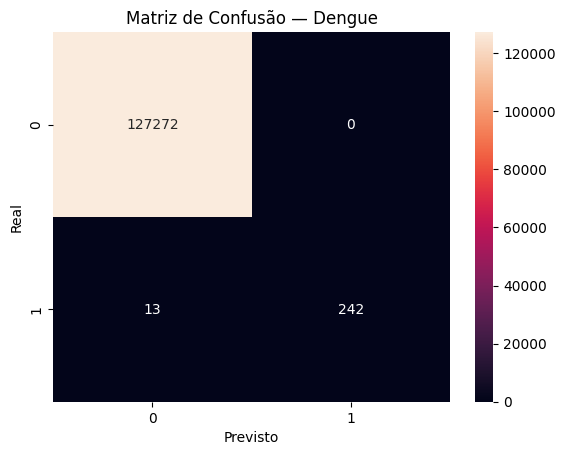

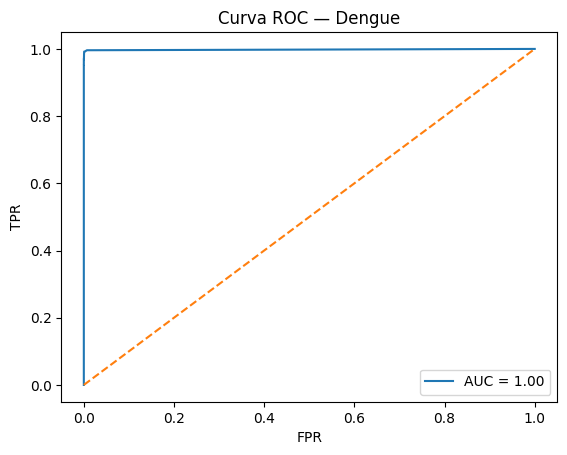

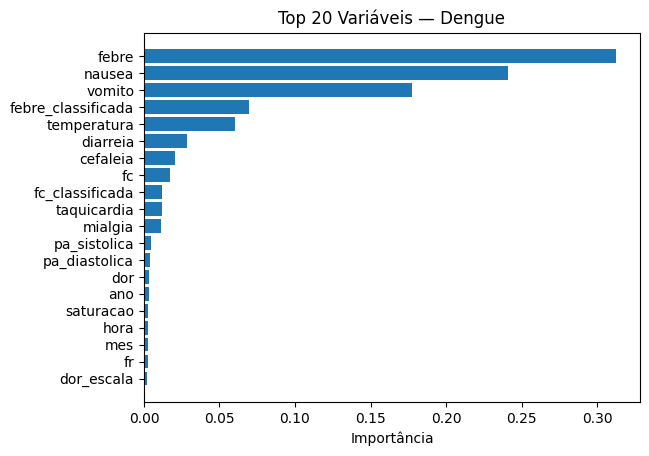

In [ ]:
cm = confusion_matrix(y_test_dengue, y_pred_dengue_ajustado)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Matriz de Confusão — Dengue')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test_dengue, y_prob_dengue)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curva ROC — Dengue')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

importancias_dengue = pd.DataFrame({
    'variavel': X_train_dengue.columns,
    'importancia': modelo_dengue.feature_importances_
}).sort_values(by='importancia', ascending=False)

top20 = importancias_dengue.head(20)

plt.figure()
plt.barh(top20['variavel'], top20['importancia'])
plt.gca().invert_yaxis()
plt.title('Top 20 Variáveis — Dengue')
plt.xlabel('Importância')
plt.show()


LEPTOSPIROSE

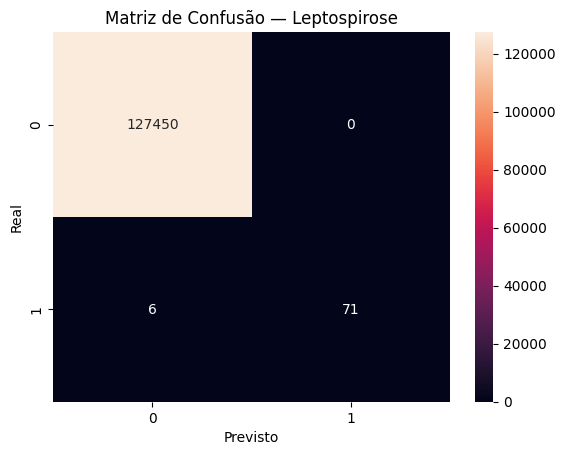

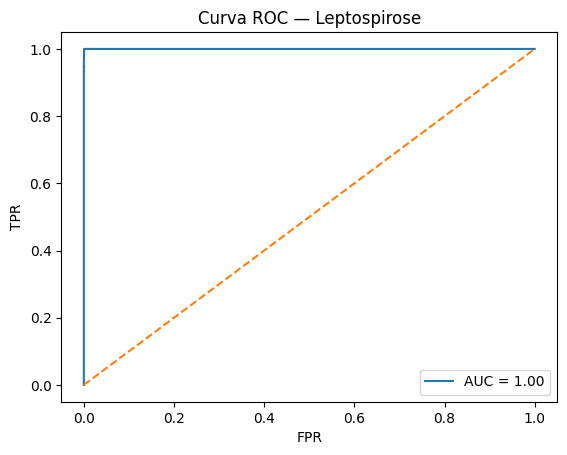

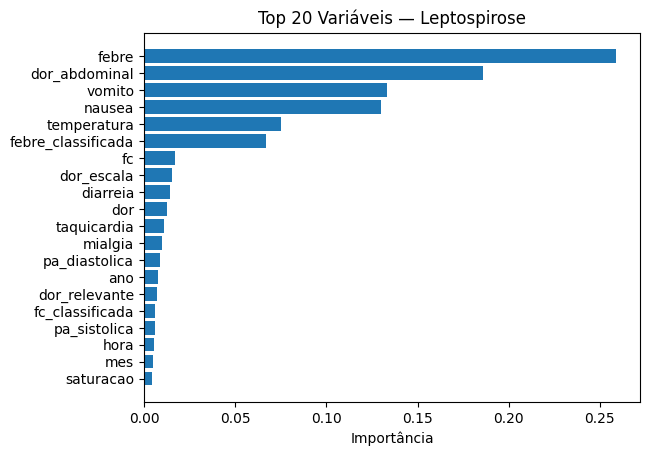

In [ ]:
cm = confusion_matrix(y_test_lepto, y_pred_lepto_ajustado)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Matriz de Confusão — Leptospirose')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test_lepto, y_prob_lepto)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curva ROC — Leptospirose')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

importancias_lepto = pd.DataFrame({
    'variavel': X_train_lepto.columns,
    'importancia': modelo_lepto.feature_importances_
}).sort_values(by='importancia', ascending=False)

top20 = importancias_lepto.head(20)

plt.figure()
plt.barh(top20['variavel'], top20['importancia'])
plt.gca().invert_yaxis()
plt.title('Top 20 Variáveis — Leptospirose')
plt.xlabel('Importância')
plt.show()


MENINGITE

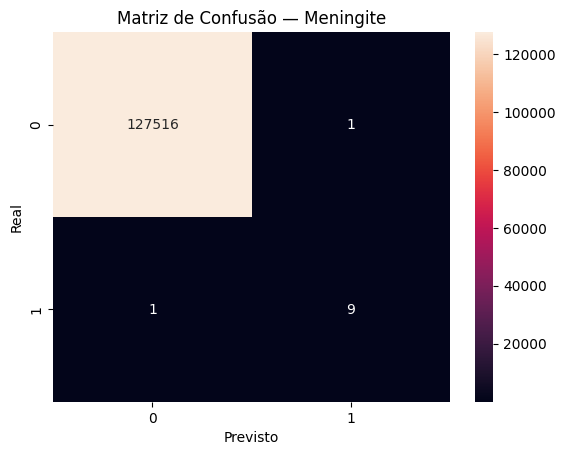

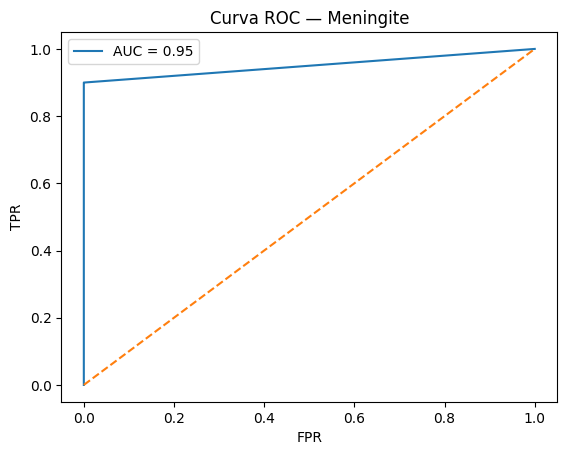

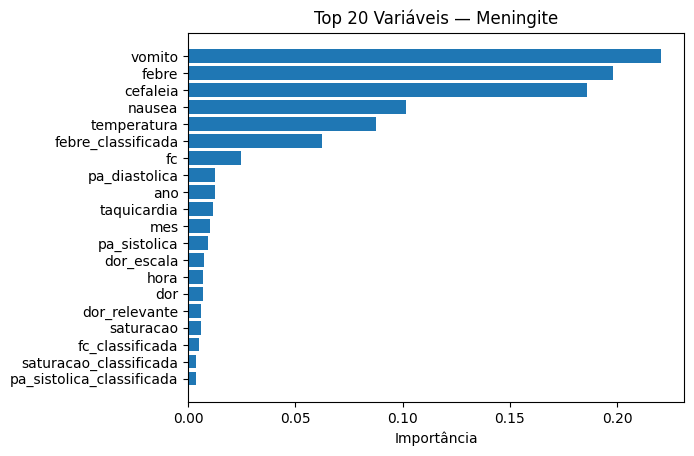

In [ ]:
cm = confusion_matrix(y_test_men, y_pred_men_ajustado)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Matriz de Confusão — Meningite')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test_men, y_prob_men)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curva ROC — Meningite')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

importancias_men = pd.DataFrame({
    'variavel': X_train_men.columns,
    'importancia': modelo_meningite.feature_importances_
}).sort_values(by='importancia', ascending=False)

top20 = importancias_men.head(20)

plt.figure()
plt.barh(top20['variavel'], top20['importancia'])
plt.gca().invert_yaxis()
plt.title('Top 20 Variáveis — Meningite')
plt.xlabel('Importância')
plt.show()


## 11. **INTEGRAÇÃO DE ALERTAS**

Após a validação dos modelos, foi criado um alerta integrado para consolidar as suspeitas identificadas.

O sistema classifica cada atendimento como:

- Sem alerta
- Alerta: Dengue
- Alerta: Leptospirose
- Alerta: Meningite
- Alertas combinados

Essa estrutura permite identificar casos simples e casos com suspeitas múltiplas, apoiando a priorização da vigilância epidemiológica.

In [ ]:
df_modelo['prob_dengue'] = modelo_dengue.predict_proba(X_dengue)[:, 1]
df_modelo['prob_leptospirose'] = modelo_lepto.predict_proba(X_lepto)[:, 1]
df_modelo['prob_meningite'] = modelo_meningite.predict_proba(X_meningite)[:, 1]

limiar_dengue = 0.3
limiar_leptospirose = 0.2
limiar_meningite = 0.1

df_modelo['alerta_dengue'] = (df_modelo['prob_dengue'] > limiar_dengue).astype(int)
df_modelo['alerta_leptospirose'] = (df_modelo['prob_leptospirose'] > limiar_leptospirose).astype(int)
df_modelo['alerta_meningite'] = (df_modelo['prob_meningite'] > limiar_meningite).astype(int)

def gerar_alerta_integrado(row):
    alertas = []

    if row['alerta_dengue'] == 1:
        alertas.append('Dengue')

    if row['alerta_leptospirose'] == 1:
        alertas.append('Leptospirose')

    if row['alerta_meningite'] == 1:
        alertas.append('Meningite')

    if len(alertas) == 0:
        return 'Sem alerta'

    return 'Alerta: ' + ', '.join(alertas)

df_modelo['alerta_sivig'] = df_modelo.apply(gerar_alerta_integrado, axis=1)

df_modelo['necessita_notificacao'] = (
    df_modelo['alerta_sivig'] != 'Sem alerta'
).astype(int)

df_modelo['status_vigilancia'] = df_modelo['necessita_notificacao'].apply(
    lambda x: 'Aguardando avaliação da Vigilância' if x == 1 else 'Sem necessidade de alerta'
)

df_modelo['solicitar_sinan'] = df_modelo['necessita_notificacao'].apply(
    lambda x: 'Sim' if x == 1 else 'Não'
)

print("Distribuição dos alertas:")
display(df_modelo['alerta_sivig'].value_counts())


Distribuição dos alertas:


,count
alerta_sivig,
Sem alerta,424153
Alerta: Dengue,653
"Alerta: Dengue, Leptospirose",152
Alerta: Leptospirose,95
"Alerta: Dengue, Meningite",31
"Alerta: Dengue, Leptospirose, Meningite",2
"Alerta: Leptospirose, Meningite",1


In [ ]:
casos_alerta = df_modelo[df_modelo['alerta_sivig'] != 'Sem alerta'].copy()

colunas_visualizacao = [
    'subject_id',
    'stay_id',
    'queixa_principal',
    'prob_dengue',
    'prob_leptospirose',
    'prob_meningite',
    'alerta_sivig',
    'status_vigilancia',
    'solicitar_sinan'
]

display(casos_alerta[[col for col in colunas_visualizacao if col in casos_alerta.columns]].head(50))

print("Total de casos com alerta:", casos_alerta.shape[0])


,subject_id,stay_id,queixa_principal,prob_dengue,prob_leptospirose,prob_meningite,alerta_sivig,status_vigilancia,solicitar_sinan
370,10008304,30872939,"malaise,n/v",0.97,0.04,0.00,Alerta: Dengue,Aguardando avaliação da Vigilância,Sim
371,10008304,35990983,"fever, n/v, body pain",0.96,0.02,0.00,Alerta: Dengue,Aguardando avaliação da Vigilância,Sim
1072,10024170,35981522,"fever, n/v, anorexia",0.64,0.02,0.00,Alerta: Dengue,Aguardando avaliação da Vigilância,Sim
1884,10040590,38940399,"n/v/d, fever",0.89,0.07,0.01,Alerta: Dengue,Aguardando avaliação da Vigilância,Sim
1990,10043177,33606107,n/v/d,0.99,0.05,0.00,Alerta: Dengue,Aguardando avaliação da Vigilância,Sim
2113,10046503,36502759,"n/v, fever",0.99,0.02,0.00,Alerta: Dengue,Aguardando avaliação da Vigilância,Sim
3111,10075035,39116973,"fever, n/v, r shoulder pain",0.96,0.01,0.00,Alerta: Dengue,Aguardando avaliação da Vigilância,Sim
3578,10087922,36459068,"fever, n/v",0.99,0.01,0.00,Alerta: Dengue,Aguardando avaliação da Vigilância,Sim
3987,10098778,34414819,n/v,0.96,0.03,0.02,Alerta: Dengue,Aguardando avaliação da Vigilância,Sim
4152,10103763,36173942,"fever, n/v, transfer",0.92,0.01,0.00,Alerta: Dengue,Aguardando avaliação da Vigilância,Sim


Total de casos com alerta: 934


In [ ]:
df_modelo.to_csv("SIVIG_BASE_FINAL_COM_ALERTA_INTEGRADO.csv", index=False)

print("Base final com alerta integrado salva em CSV.")


Base final com alerta integrado salva em CSV.


## 12. **ESPELHAMENTO DE FICHA DE INVESTIFAÇÃO - FIE-SINAN**

O projeto inclui uma proposta de espelhamento das fichas SINAN para dengue, leptospirose e meningite.

O objetivo é que, ao gerar um alerta, o sistema selecione a ficha correspondente ao agravo suspeito e pré-preencha campos clínicos disponíveis, como febre, cefaleia, vômito, icterícia, convulsão e outros sinais relevantes.

Essa etapa representa uma proposta conceitual de integração entre triagem, vigilância epidemiológica e notificação compulsória.

As fichas oficiais usadas no projeto trazem campos clínicos compatíveis com as variáveis modeladas: a ficha de leptospirose inclui febre, mialgia, cefaleia, vômito, icterícia, diarreia e alterações respiratórias; a ficha de dengue inclui manifestações como febre, náuseas, vômitos, mialgia, cefaleia e dor retroorbital; e a ficha de meningite inclui febre, cefaleia, vômitos, convulsões, rigidez de nuca e petéquias/sufusões hemorrágicas.

In [ ]:
def sim_nao(valor):
    return 'Sim' if valor == 1 else 'Não'

def definir_ficha_sinan(row):
    alerta = row.get("alerta_sivig", "")

    if "Dengue" in alerta:
        return "FIE Dengue / Chikungunya"

    if "Leptospirose" in alerta:
        return "FIE Leptospirose"

    if "Meningite" in alerta:
        return "FIE Meningite"

    return "Sem ficha"

def montar_espelhamento_fie(row):
    alerta = row.get("alerta_sivig", "")

    texto_base = f"""
📄 ESPELHAMENTO DA FICHA SINAN

Tipo de notificação: Individual
Paciente ID: {row.get('subject_id', 'N/A')}
Atendimento ID: {row.get('stay_id', 'N/A')}
Ficha sugerida: {definir_ficha_sinan(row)}
Alerta gerado: {row.get('alerta_sivig', 'Sem alerta')}

📊 Probabilidades calculadas pela IA:
- Dengue: {row.get('prob_dengue', 0):.2%}
- Leptospirose: {row.get('prob_leptospirose', 0):.2%}
- Meningite: {row.get('prob_meningite', 0):.2%}
"""

    if "Dengue" in alerta:
        texto_base += f"""

🦟 CAMPOS ESPELHADOS — FIE DENGUE / CHIKUNGUNYA

- Febre: {sim_nao(row.get('febre', 0))}
- Cefaleia: {sim_nao(row.get('cefaleia', 0))}
- Náuseas: {sim_nao(row.get('nausea', 0))}
- Vômito: {sim_nao(row.get('vomito', 0))}
- Mialgia/Dor: {sim_nao(row.get('dor', 0))}
- Dor abdominal: {sim_nao(row.get('dor_abdominal', 0))}
- Hipotensão: {sim_nao(row.get('hipotensao', 0))}
- Taquicardia: {sim_nao(row.get('taquicardia', 0))}
"""

    if "Leptospirose" in alerta:
        texto_base += f"""

🐀 CAMPOS ESPELHADOS — FIE LEPTOSPIROSE

- Febre: {sim_nao(row.get('febre', 0))}
- Mialgia/Dor: {sim_nao(row.get('dor', 0))}
- Cefaleia: {sim_nao(row.get('cefaleia', 0))}
- Vômito: {sim_nao(row.get('vomito', 0))}
- Diarreia: {sim_nao(row.get('diarreia', 0))}
- Icterícia: {sim_nao(row.get('ictericia', 0))}
- Dispneia/alterações respiratórias: {sim_nao(row.get('dispneia', 0))}
- Hipotensão: {sim_nao(row.get('hipotensao', 0))}
"""

    if "Meningite" in alerta:
        texto_base += f"""

🧠 CAMPOS ESPELHADOS — FIE MENINGITE

- Febre: {sim_nao(row.get('febre', 0))}
- Cefaleia: {sim_nao(row.get('cefaleia', 0))}
- Vômitos: {sim_nao(row.get('vomito', 0))}
- Convulsões: {sim_nao(row.get('convulsao', 0))}
- Rigidez de nuca: {sim_nao(row.get('rigidez_nuca', 0))}
- Petéquias/sufusões hemorrágicas: {sim_nao(row.get('petequias', 0))}
"""

    texto_base += """

📌 AÇÃO PARA VIGILÂNCIA
- Validar os dados clínicos espelhados.
- Complementar campos ausentes da FIE.
- Registrar número SINAN.
- Acompanhar investigação e desfecho do caso.

Sistema SIVIG-GILQ
"""

    return texto_base

casos_alerta['ficha_sugerida'] = casos_alerta.apply(definir_ficha_sinan, axis=1)
casos_alerta['mensagem_alerta'] = casos_alerta.apply(montar_espelhamento_fie, axis=1)

print("Espelhamento das fichas criado.")
print(casos_alerta['mensagem_alerta'].iloc[0])


Espelhamento das fichas criado.

📄 ESPELHAMENTO DA FICHA SINAN

Tipo de notificação: Individual
Paciente ID: 10008304
Atendimento ID: 30872939
Ficha sugerida: FIE Dengue / Chikungunya
Alerta gerado: Alerta: Dengue

📊 Probabilidades calculadas pela IA:
- Dengue: 97.00%
- Leptospirose: 4.00%
- Meningite: 0.00%


🦟 CAMPOS ESPELHADOS — FIE DENGUE / CHIKUNGUNYA

- Febre: Sim
- Cefaleia: Não
- Náuseas: Sim
- Vômito: Sim
- Mialgia/Dor: Não
- Dor abdominal: Não
- Hipotensão: Não
- Taquicardia: Sim


📌 AÇÃO PARA VIGILÂNCIA
- Validar os dados clínicos espelhados.
- Complementar campos ausentes da FIE.
- Registrar número SINAN.
- Acompanhar investigação e desfecho do caso.

Sistema SIVIG-GILQ



In [ ]:
colunas_exportar = [
    'subject_id',
    'stay_id',
    'alerta_sivig',
    'prob_dengue',
    'prob_leptospirose',
    'prob_meningite',
    'ficha_sugerida',
    'status_vigilancia',
    'solicitar_sinan',
    'mensagem_alerta'
]

casos_alerta_exportacao = casos_alerta[
    [col for col in colunas_exportar if col in casos_alerta.columns]
].copy()

casos_alerta_exportacao.to_excel(
    "SIVIG_ALERTAS_OPERACIONAIS.xlsx",
    index=False
)

print("Planilha de alertas gerada: SIVIG_ALERTAS_OPERACIONAIS.xlsx")


Planilha de alertas gerada: SIVIG_ALERTAS_OPERACIONAIS.xlsx


## 13. **DESAFIOS**

Durante o desenvolvimento do projeto, os principais desafios foram:

1. Presença de ruídos semânticos na queixa principal.
2. Termos clínicos registrados em linguagem leiga.
3. Necessidade de transformar texto livre em variáveis estruturadas.
4. Desbalanceamento das classes, especialmente para meningite.
5. Ajuste de limiares para priorizar sensibilidade em doenças graves.
6. Limitações de memória no ambiente Colab ao manipular bases grandes.
7. Integração conceitual com fichas SINAN e fluxo de vigilância.

## 14. **LIMITAÇÕES**

O projeto apresenta algumas limitações:

- Os dados utilizados não pertencem diretamente ao contexto brasileiro do SINAN.
- As variáveis foram criadas por regras clínicas e não por diagnóstico laboratorial confirmado.
- O modelo não substitui a avaliação profissional.
- O espelhamento da ficha SINAN foi desenvolvido como proposta conceitual.
- A qualidade do alerta depende da qualidade do dado registrado na triagem.

## 15. **CONCLUSÕES**

O projeto SIVIG-GILQ demonstrou que dados simples de triagem podem ser utilizados para apoiar a detecção precoce de doenças e/ou agravos de notificação compulsória.

A aplicação de Data Mining permitiu transformar sinais vitais e queixas clínicas em variáveis estruturadas, construir modelos preditivos e gerar alertas integrados para apoio à vigilância epidemiológica.

O sistema proposto não substitui o profissional de saúde, mas atua como ferramenta de apoio à decisão, contribuindo para maior sensibilidade na identificação de casos suspeitos e para a organização do fluxo de notificação.

## 16. **PASSOS FUTUROS**

Como evolução futura, o SIVIG-GILQ poderá incluir:

- envio automatizado de alertas por e-mail;
- retorno da vigilância com número SINAN;
- integração com prontuário eletrônico;
- geração automática de PDF da FIE;
- dashboard de monitoramento epidemiológico;
- validação com dados reais do contexto brasileiro.